# **Distribuição de Probabilidade**




Uma distribuição de probabilidade descreve o comportamento de variáveis aleatórias, indicando as probabilidades associadas aos seus possíveis resultados. Os modelos matemáticos utilizados para representar o comportamento das variáveis dependem do tipo de variável analisada. Por exemplo, a distribuição binomial é utilizada para representar variáveis discretas, enquanto a distribuição normal é aplicada para variáveis contínuas. A seguir, são apresentados esses modelos, bem como exemplos de aplicação.

#**Distribuição Binomial**


A distribuição binomial é aplicada em casos de experimentos repetidos, nos quais cada tentativa possui apenas dois possíveis resultados, como cara ou coroa, sucesso ou fracasso, imóveis titulados ou não titulados, e etc.

Levando em consideração que:

* n = número de tentativas

* p = probabilidade de sucesso em cada tentativa

* (1-p) = probabilidade de falha em cada tentativa

* X = Número de sucessos em n tentativas independentes


É utilizada a seguinte função massa de probabilidade:

$$
p_X(x) = P(X = x) = \binom{n}{x}p^x(1-p)^{n-x}
$$

em que:

$$
\binom{n}{x}= \frac{n!}{x!(n-x)!}
$$

para x= 0, 1, ..., n


**Exemplo - Aplicação da distribuição binomial**

Em um levantamento cadastral realizado em imóveis localizados em um núcleo urbano informal no município do interior da Bahia, sabe-se que a probabilidade de um imóvel possuir titulação é de 15%. Se forem selecionado aleatoriamente 50 imóveis, qual é a probabilidade de que nenhum imóvel tenha titulação formal? Pelo menos 5 imóveis tenha titulação formal?

A probabilidade de nenhuma imóvel ter titulação é: 0.0003
A probabilidade de pelo menos menos dez imóveis terem titulação: 0.2089


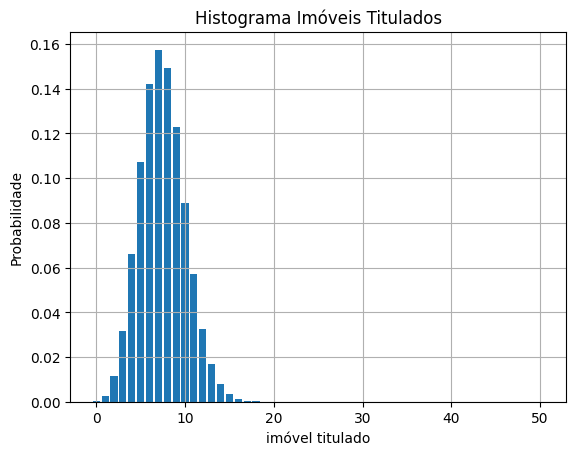

In [12]:
from scipy.stats import binom

# Definindo os parâmetros da distribuição binomial
n = 50  # Número total de tentativas (imóveis selecionados)
p = 0.15 # Probabilidade de sucesso em cada tentativa (imóvel com titulação)

# a) Probabilidade de nenhum imóvel ter titulação (x = 0)
prob_nenhum_titulo = binom.pmf(0, n, p)
print(f"A probabilidade de nenhuma imóvel ter titulação é: {prob_nenhum_titulo:.4f}")

# b) Probabilidade de pelo menos dez imóveis terem titulação (x >= 10)
# Podemos calcular isso como 1 - (probabilidade de dar menor ou igual 9)
prob_pelo_menos_10_imoveis =1- binom.cdf(9, n, p)
print(f"A probabilidade de pelo menos menos dez imóveis terem titulação: {prob_pelo_menos_10_imoveis:.4f}")

# Gerando o gráfico da distribuição binomial deste exemplo:
import matplotlib.pyplot as plt
rv = binom(n, p)
resultado = rv.pmf(range(0,51,1))

plt.bar(range(0,51,1),resultado)

plt.xlabel('imóvel titulado')
plt.ylabel('Probabilidade')
plt.title('Distribuição binomial dos imóveis titulados')
plt.grid(True)
plt.show()



#**Distribuição normal**

A distribuição normal é um dos modelos mais conhecidos e utilizados na estatística, sendo caracterizada por um curva com o formato de um sino.

Essa distribuição é definida por dois parâmetros: média $\mu$, e desvio padrão $\sigma$. Podendo também ser representada pela média $\mu$ e a variância $\sigma^2$.

Nessa distribuição, a variável X é contínua e pode assumir qualquer valor real:

$-∞ < x < +∞.

Algumas caracteríticas dessa curva são:

* Trata-se de uma curva
simétrica, em que a média representa o ponto mais alto da curva;

* a média, a mediana e a moda possuem o mesmo valor;

* A média pode ser um valor positivo, zero ou negativo;

* O desvio padrão indica o nível de achatamanento da curva.Quanto maior o desvio padrão, maior a variabilidade e mais achatada é a curva.

* As probabilidades de uma variável são dadas pela área sob a curva, que tem área total igual a 1.

Assim, é possível calcular a proporção de área sob a curva para dois valores específicos, o que representa a probabilidade de a variável assumir valores dentro desse intervalo.

Em uma distribuição Normal, aproximadamente 68,3% dos valores estão a até um desvio padrão da média, 95,5% estão a até dois desvios padrão e 99,7% estão a até três desvios padrão, conforme tabela abaixo:

|Tamanho|Proporção|
| :-: | :-: |
| $\mu \pm 1\sigma$ |68.3%|
| $\mu \pm 2\sigma$ |95.5%|
| $\mu \pm 3\sigma$ |99.7%|


A fim de facilitar o cálculo da probabilidade em uma dada distribuição normal, utiliza-se a distribuição normal padronizada, cujos valores de probabilidade são tabelados e que possui $\mu=0 ~ e ~\sigma^2=1$.

Para padronizar um variável aleatória (X) de uma distribuição normal qualquer N ($\mu$,$\sigma^2$), calcula-se uma nova variável aleatória Z, chamada variável aleatória normal padronizada, dada por:

$$
Z=\frac{X-\mu}{\sigma}
$$

Após calculado o valor de Z, é possível encontrar na tabela de distribuição normal padronizada a área associada a esse valor. Dependendo do tipo de tabela utilizada, essa área pode representar a probabilidade acumulada a esquerda de Z, ou a área entre a média e o valor de Z. A partir dessas informações, é possível obter a área entre dois pontos sob a curva, que representa a probabilidade da variável assumir valores dentro desse intervalo.

**Exemplo - Aplicação da distribuição normal:**

Em um estudo sobre os imóveis localizados em um determinado núcleo informa objeto da Reurb, foi analisada a diferença entre a área registrada no cartório e a área obtida no levantamento cadastral. Considerando que essas diferenças seguem uma distrobuição normal, com média 5 e desvio padrão 15 m², qual a probabilidade a probabilidade de um imóvel apresentar diferença superior a 20 m² entre a área cadastrada e a área levantada em campo? e a diferença entre as áreas estar entre −10 m² e 10 m².



In [22]:
from scipy.stats import norm

# Definindo os parâmetros da distribuição normal
media = 0  # Média da diferença entre as áreas calculadas (em m²)
desvio_padrao = 15  # Desvio padrão diferença entre as áreas calculadas (em m²)

# a) Probabilidade da diferença entre as áreas ser superior a 20 m² (P(X > 20))
# Usamos a função de distribuição cumulativa (cdf)
prob_superior_20 = norm.sf(20, media, desvio_padrao)
print(f"A probabilidade da diferença entre as áreas ser superior a 20 m² é: {prob_superior_20:.4f}")

# b) Probabilidade da diferença entre as áreas estar entre - 10 e 10 m² (P(-10 < X < 10))
# Calculamos a cdf em 10 e subtraímos a cdf em -10
prob_entre_menos10_e_10 = norm.cdf(10, media, desvio_padrao) - (norm.cdf(-10, media, desvio_padrao))
print(f"A probabilidade da diferença entre as áreas estar entre -10 e 10 m² é: {prob_entre_menos10_e_10:.4f}")


A probabilidade da diferença entre as áreas ser superior a 20 m² é: 0.0912
A probabilidade da diferença entre as áreas estar entre -10 e 10 m² é: 0.4950
